# Warsaw Public Transit Telemetry: Delay & Traffic Overview

This notebook provides a comprehensive exploratory visualization of the **live transit delay telemetry** dataset collected from the Warsaw public transit system (ZTM / GTFS-RT Warsaw).

### Dataset Highlights
- **Volume**: Over **11.14 million telemetry observations** spanning 7 continuous days (Oct 4 – Oct 10, 2026)
- **Network Scale**: 316 routes, 3,622 vehicles, 6,848 unique stops, and 89,816 vehicle trips
- **Resolution**: Polled every 30 seconds via GTFS-RT Protocol Buffers and stored in Hive-partitioned Apache Parquet partitions

### Contents
1. **High-Performance Querying via DuckDB**
2. **Daily Ingestion & Operational Trends**
3. **Arrival Delay Distribution & Anomaly Filtering**
4. **Diurnal Delay Curve: Peak vs. Off-Peak Hours**
5. **Route-Level Delay Attribution (Trams vs. Buses)**
6. **Geospatial Stop Delay Hotspot Mapping**

In [4]:
import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica', 'Arial', 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.dpi'] = 120

# Robust path resolution regardless of working directory (root or dataoverview/)
if os.path.exists('../data/raw'):
    DATA_DIR = '../data'
elif os.path.exists('data/raw'):
    DATA_DIR = 'data'
else:
    DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))

RAW_DATA_PATH = os.path.join(DATA_DIR, 'raw/**/*.parquet')
GTFS_STOPS_PATH = os.path.join(DATA_DIR, 'gtfs/2026_10_04/stops.txt')

con = duckdb.connect(':memory:')
print('DuckDB initialized successfully.')
print('Raw telemetry source:', RAW_DATA_PATH)

DuckDB initialized successfully.
Raw telemetry source: ../data/raw/**/*.parquet


## 1. High-Level Dataset Inventory
Using DuckDB's vectorized Parquet engine to scan across all daily partitions without loading 11M rows into RAM.

In [5]:
inventory_df = con.execute(f'''
    SELECT 
        COUNT(*) AS total_records,
        COUNT(DISTINCT trip_id) AS distinct_trips,
        COUNT(DISTINCT route_id) AS distinct_routes,
        COUNT(DISTINCT vehicle_id) AS distinct_vehicles,
        COUNT(DISTINCT stop_id) AS distinct_stops,
        MIN(to_timestamp(feed_timestamp)) AS start_timestamp,
        MAX(to_timestamp(feed_timestamp)) AS end_timestamp
    FROM read_parquet('{RAW_DATA_PATH}', hive_partitioning=true)
''').df()

display(inventory_df)

,total_records,distinct_trips,distinct_routes,distinct_vehicles,distinct_stops,start_timestamp,end_timestamp
0,11139564,89816,316,3622,6848,2026-10-04 14:09:30+02:00,2026-10-10 14:40:41+02:00


## 2. Daily Ingestion Volume & Operational Delay Trends
Let's inspect how many telemetry events are collected each day and how the average delay behaves between weekdays and weekends.

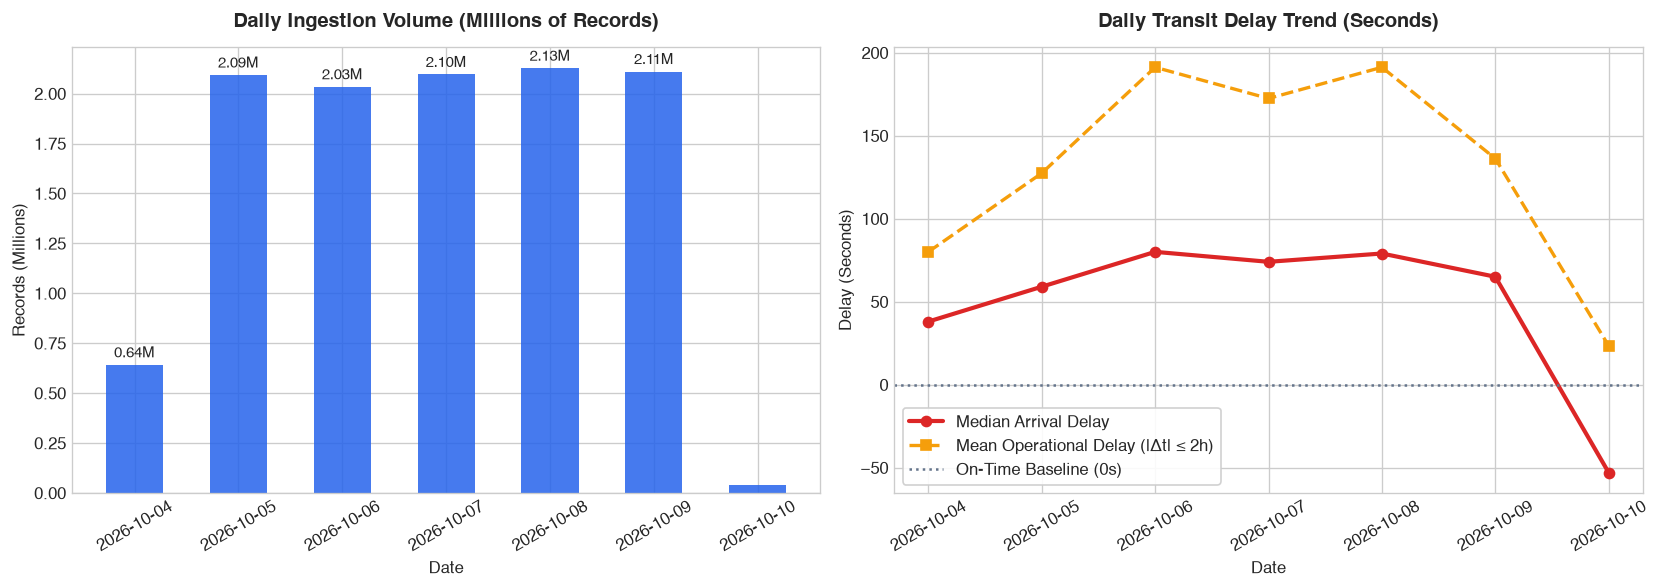

In [6]:
daily_df = con.execute(f'''
    SELECT 
        year || '-' || month || '-' || day AS date_str,
        COUNT(*) AS records,
        COUNT(DISTINCT trip_id) AS active_trips,
        COUNT(DISTINCT vehicle_id) AS active_vehicles,
        ROUND(AVG(arrival_delay_seconds), 1) AS mean_raw_delay,
        ROUND(MEDIAN(arrival_delay_seconds), 1) AS median_delay,
        ROUND(AVG(CASE WHEN ABS(arrival_delay_seconds) <= 7200 THEN arrival_delay_seconds ELSE NULL END), 1) AS mean_operational_delay
    FROM read_parquet('{RAW_DATA_PATH}', hive_partitioning=true)
    GROUP BY year, month, day
    ORDER BY year, month, day
''').df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Daily Records Ingested
bars = ax1.bar(daily_df['date_str'], daily_df['records'] / 1e6, color='#2563eb', alpha=0.85, width=0.55)
ax1.set_title('Daily Ingestion Volume (Millions of Records)', fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('Records (Millions)')
ax1.set_xlabel('Date')
ax1.tick_params(axis='x', rotation=30)
for b in bars:
    h = b.get_height()
    if h > 0.05:
        ax1.annotate(f'{h:.2f}M', (b.get_x() + b.get_width()/2, h), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

# Right: Operational Median Delay
ax2.plot(daily_df['date_str'], daily_df['median_delay'], marker='o', linewidth=2.5, color='#dc2626', label='Median Arrival Delay')
ax2.plot(daily_df['date_str'], daily_df['mean_operational_delay'], marker='s', linewidth=2, linestyle='--', color='#f59e0b', label='Mean Operational Delay (|Δt| ≤ 2h)')
ax2.axhline(0, color='#64748b', linestyle=':', label='On-Time Baseline (0s)')
ax2.set_title('Daily Transit Delay Trend (Seconds)', fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Delay (Seconds)')
ax2.set_xlabel('Date')
ax2.tick_params(axis='x', rotation=30)
ax2.legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

## 3. Arrival Delay Distribution & Anomaly Filtering

> **Domain Note on GTFS-RT Delay Anomalies**:
> GTFS-RT feeds occasionally record large negative delays (e.g. -3600s to -86400s) when vehicles are queued at depot terminals hours prior to trip departure. Similarly, cancelled trips can register persistent positive delays. For econometric & machine learning analysis, records are filtered to operational windows: $|\Delta t| \le 120\text{ minutes}$ (with zoom into $\pm 15\text{ minutes}$).

/var/folders/45/pmwnwqfd3tqf5xk9pxdg87wc0000gn/T/ipykernel_12093/1737689192.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


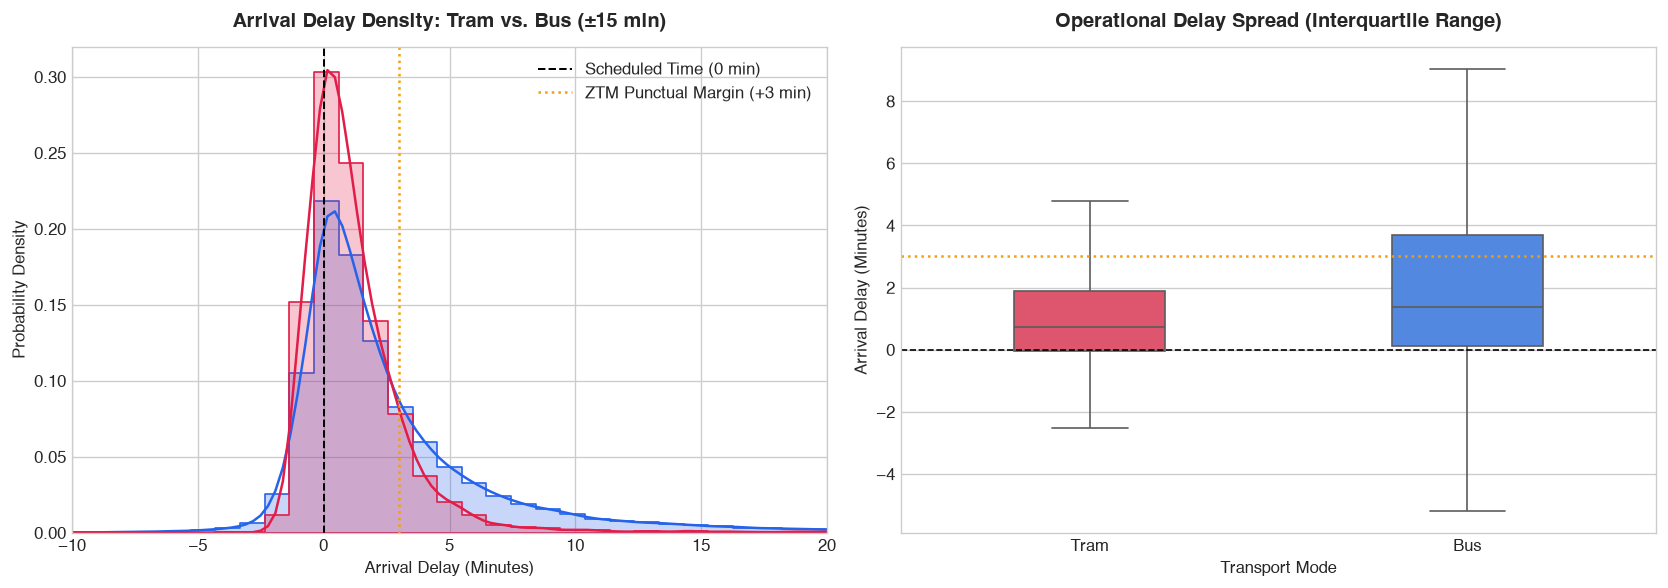

Delay Quantiles (Minutes):


,count,mean,std,min,25%,50%,75%,90%,95%,max
vehicle_mode,,,,,,,,,,
Bus,74538.0,2.631074,4.283755,-28.800000,0.116667,1.366667,3.683333,7.60,11.233333,29.983333
Tram,20066.0,1.231978,2.437055,-20.933333,-0.050000,0.716667,1.883333,3.35,4.683333,29.933333


In [7]:
# Sample 100,000 operational records for fast statistical distribution plotting
sample_delays_df = con.execute(f'''
    SELECT 
        arrival_delay_seconds / 60.0 AS delay_minutes,
        arrival_delay_seconds,
        CASE 
            WHEN TRY_CAST(route_id AS INTEGER) IS NOT NULL AND TRY_CAST(route_id AS INTEGER) < 100 THEN 'Tram' 
            ELSE 'Bus' 
        END AS vehicle_mode
    FROM read_parquet('{RAW_DATA_PATH}', hive_partitioning=true)
    WHERE ABS(arrival_delay_seconds) <= 1800  -- Within ±30 minutes
    USING SAMPLE 100000
''').df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram + KDE Distribution
sns.histplot(
    data=sample_delays_df, 
    x='delay_minutes', 
    hue='vehicle_mode', 
    kde=True, 
    bins=60, 
    palette={'Tram': '#e11d48', 'Bus': '#2563eb'}, 
    ax=ax1, 
    element='step',
    stat='density',
    common_norm=False
)
ax1.axvline(0, color='black', linestyle='--', linewidth=1.2, label='Scheduled Time (0 min)')
ax1.axvline(3, color='#f59e0b', linestyle=':', linewidth=1.5, label='ZTM Punctual Margin (+3 min)')
ax1.set_xlim(-10, 20)
ax1.set_title('Arrival Delay Density: Tram vs. Bus (±15 min)', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Arrival Delay (Minutes)')
ax1.set_ylabel('Probability Density')
ax1.legend(loc='upper right')

# Right: Boxplot by Vehicle Mode
sns.boxplot(
    data=sample_delays_df, 
    x='vehicle_mode', 
    y='delay_minutes', 
    palette={'Tram': '#f43f5e', 'Bus': '#3b82f6'}, 
    showfliers=False, 
    ax=ax2, 
    width=0.4
)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.axhline(3, color='#f59e0b', linestyle=':', label='+3 min threshold')
ax2.set_title('Operational Delay Spread (Interquartile Range)', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Transport Mode')
ax2.set_ylabel('Arrival Delay (Minutes)')

plt.tight_layout()
plt.show()

print('Delay Quantiles (Minutes):')
display(sample_delays_df.groupby('vehicle_mode')['delay_minutes'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]))

## 4. Diurnal Delay Profile: Peak vs. Off-Peak Hours
Warsaw traffic exhibits distinct morning rush hour (07:00–09:00) and evening rush hour (16:00–18:00) congestion peaks. Let's visualize the 24-hour delay curve.

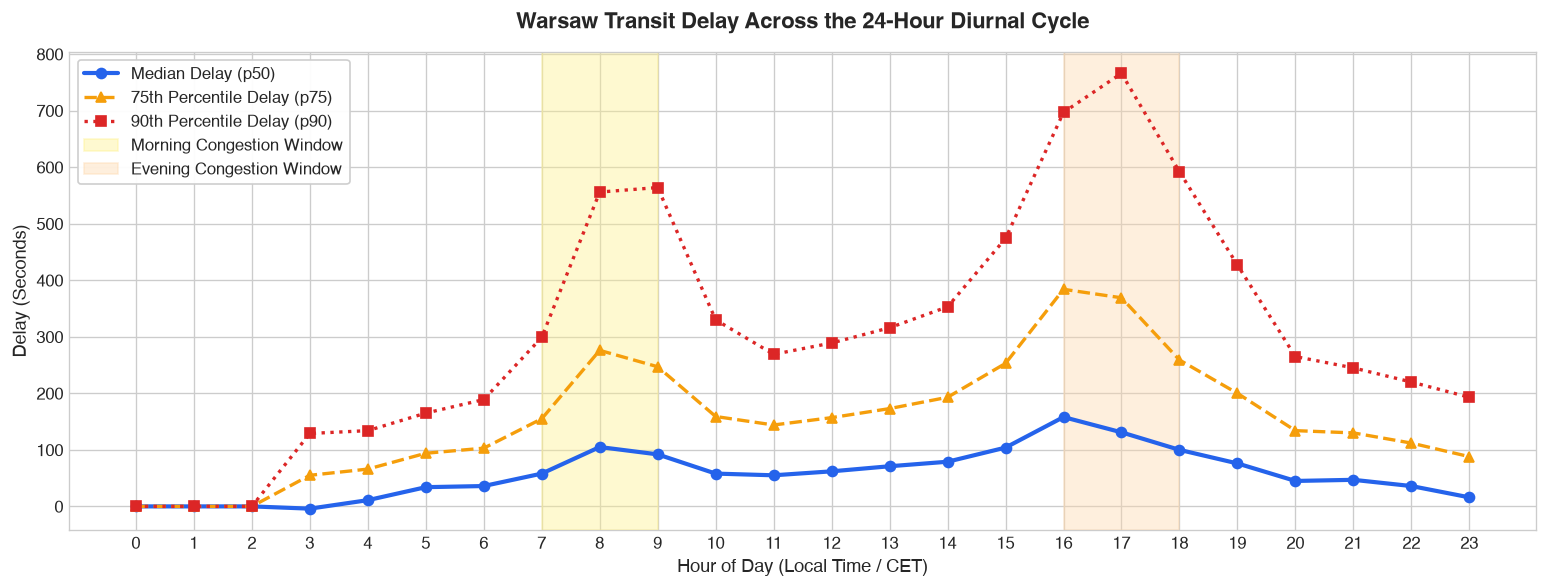

In [8]:
hourly_df = con.execute(f'''
    SELECT 
        EXTRACT(hour FROM to_timestamp(feed_timestamp)) AS hour_of_day,
        CASE 
            WHEN EXTRACT(hour FROM to_timestamp(feed_timestamp)) IN (7, 8, 9) THEN 'Morning Peak (07-09)'
            WHEN EXTRACT(hour FROM to_timestamp(feed_timestamp)) IN (16, 17, 18) THEN 'Evening Peak (16-18)'
            ELSE 'Off-Peak'
        END AS peak_category,
        ROUND(AVG(arrival_delay_seconds), 1) AS mean_delay_s,
        ROUND(MEDIAN(arrival_delay_seconds), 1) AS median_delay_s,
        ROUND(QUANTILE_CONT(arrival_delay_seconds, 0.75), 1) AS p75_delay_s,
        ROUND(QUANTILE_CONT(arrival_delay_seconds, 0.90), 1) AS p90_delay_s,
        COUNT(*) AS obs_count
    FROM read_parquet('{RAW_DATA_PATH}', hive_partitioning=true)
    WHERE ABS(arrival_delay_seconds) <= 3600  -- Filter extreme anomalies
    GROUP BY hour_of_day, peak_category
    ORDER BY hour_of_day
''').df()

plt.figure(figsize=(13, 5))
plt.plot(hourly_df['hour_of_day'], hourly_df['median_delay_s'], marker='o', linewidth=2.5, color='#2563eb', label='Median Delay (p50)')
plt.plot(hourly_df['hour_of_day'], hourly_df['p75_delay_s'], marker='^', linewidth=2, linestyle='--', color='#f59e0b', label='75th Percentile Delay (p75)')
plt.plot(hourly_df['hour_of_day'], hourly_df['p90_delay_s'], marker='s', linewidth=2, linestyle=':', color='#dc2626', label='90th Percentile Delay (p90)')

# Highlight peak hours
plt.axvspan(7, 9, color='#fef08a', alpha=0.4, label='Morning Congestion Window')
plt.axvspan(16, 18, color='#fed7aa', alpha=0.4, label='Evening Congestion Window')

plt.title('Warsaw Transit Delay Across the 24-Hour Diurnal Cycle', fontsize=13, fontweight='bold', pad=14)
plt.xlabel('Hour of Day (Local Time / CET)', fontsize=11)
plt.ylabel('Delay (Seconds)', fontsize=11)
plt.xticks(range(0, 24))
plt.legend(frameon=True, facecolor='white', framealpha=0.95, loc='upper left')
plt.tight_layout()
plt.show()

## 5. Route-Level Delay Attribution: Top Delayed vs. Most Punctual Routes
Identifying lines with high vulnerability to traffic friction across the Warsaw metropolitan network.

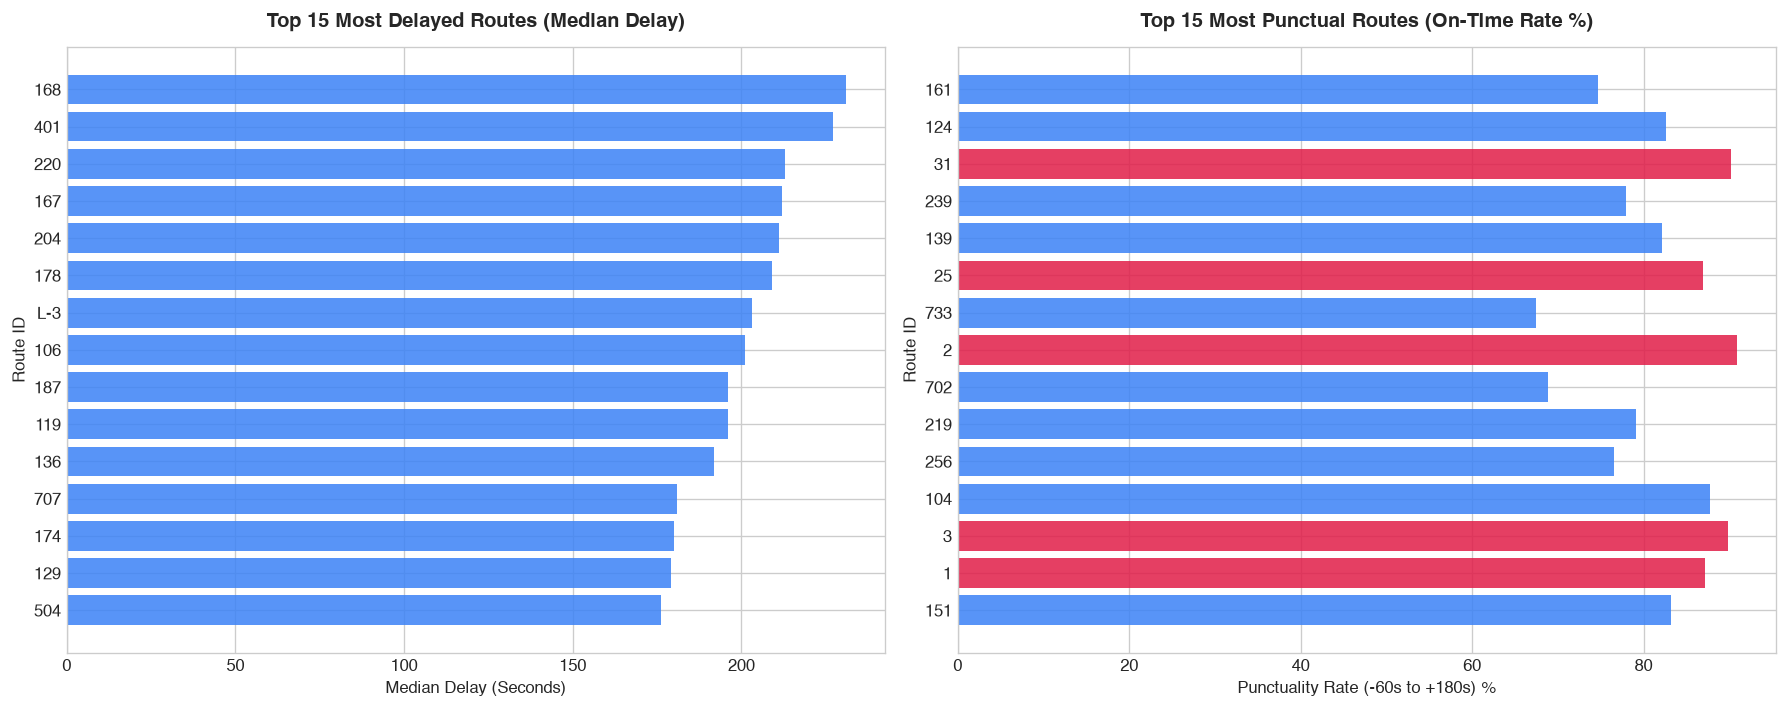

In [9]:
route_stats_df = con.execute(f'''
    SELECT 
        route_id,
        CASE 
            WHEN TRY_CAST(route_id AS INTEGER) IS NOT NULL AND TRY_CAST(route_id AS INTEGER) < 100 THEN 'Tram' 
            ELSE 'Bus' 
        END AS mode,
        COUNT(*) AS total_pings,
        ROUND(AVG(arrival_delay_seconds), 1) AS avg_delay_s,
        ROUND(MEDIAN(arrival_delay_seconds), 1) AS median_delay_s,
        ROUND(100.0 * SUM(CASE WHEN arrival_delay_seconds <= 180 AND arrival_delay_seconds >= -60 THEN 1 ELSE 0 END) / COUNT(*), 1) AS on_time_rate_pct
    FROM read_parquet('{RAW_DATA_PATH}', hive_partitioning=true)
    WHERE ABS(arrival_delay_seconds) <= 3600
    GROUP BY route_id, mode
    HAVING COUNT(*) >= 5000
    ORDER BY median_delay_s DESC
''').df()

top_delayed = route_stats_df.head(15)
top_punctual = route_stats_df.tail(15).iloc[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Top Delayed
colors_del = ['#e11d48' if m == 'Tram' else '#3b82f6' for m in top_delayed['mode']]
ax1.barh(top_delayed['route_id'].astype(str), top_delayed['median_delay_s'], color=colors_del, alpha=0.85)
ax1.invert_yaxis()
ax1.set_title('Top 15 Most Delayed Routes (Median Delay)', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Median Delay (Seconds)')
ax1.set_ylabel('Route ID')

# Top Punctual
colors_punc = ['#e11d48' if m == 'Tram' else '#3b82f6' for m in top_punctual['mode']]
ax2.barh(top_punctual['route_id'].astype(str), top_punctual['on_time_rate_pct'], color=colors_punc, alpha=0.85)
ax2.invert_yaxis()
ax2.set_title('Top 15 Most Punctual Routes (On-Time Rate %)', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Punctuality Rate (-60s to +180s) %')
ax2.set_ylabel('Route ID')

plt.tight_layout()
plt.show()

## 6. Geospatial Stop Delay Hotspot Mapping
Aggregating average delays at the physical stop level by joining with static GTFS stop coordinates.

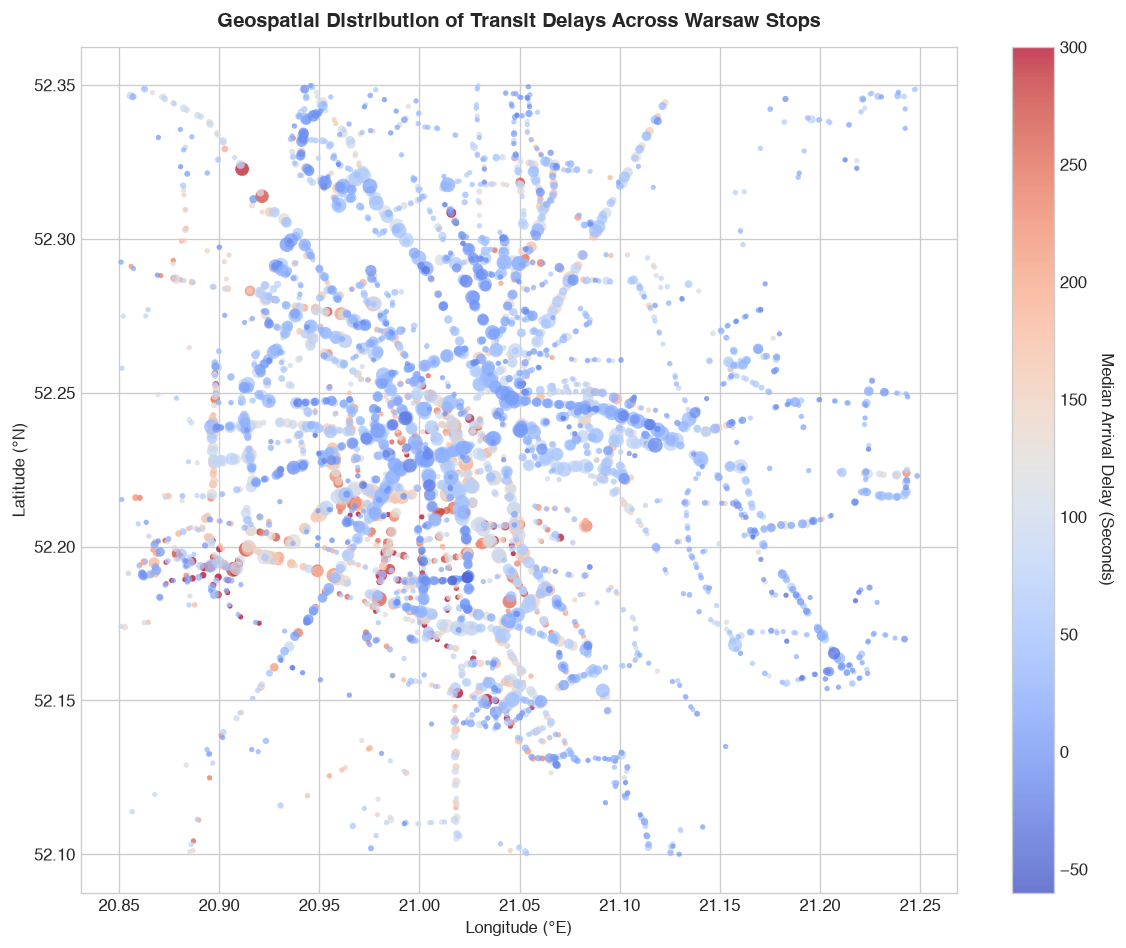

Top 5 Most Congested Stops in Warsaw:


,stop_id,stop_name,median_delay_s,ping_count
0,108901,Odlewnicza,573.0,1192
1,314001,Stryjeńskich,560.5,856
2,323402,Stefana Batorego,556.0,790
3,704301,Nowy Świat,555.0,807
4,330101,Malinowskiego,529.0,1607


In [10]:
stops_geo_df = con.execute(f'''
    WITH stop_delays AS (
        SELECT 
            stop_id,
            COUNT(*) AS ping_count,
            ROUND(AVG(arrival_delay_seconds), 1) AS mean_delay_s,
            ROUND(MEDIAN(arrival_delay_seconds), 1) AS median_delay_s
        FROM read_parquet('{RAW_DATA_PATH}', hive_partitioning=true)
        WHERE ABS(arrival_delay_seconds) <= 1800
        GROUP BY stop_id
        HAVING COUNT(*) >= 500
    )
    SELECT 
        s.stop_id,
        s.stop_name,
        s.stop_lat,
        s.stop_lon,
        d.ping_count,
        d.mean_delay_s,
        d.median_delay_s
    FROM stop_delays d
    JOIN read_csv_auto('{GTFS_STOPS_PATH}') s ON CAST(d.stop_id AS VARCHAR) = CAST(s.stop_id AS VARCHAR)
    WHERE s.stop_lat BETWEEN 52.10 AND 52.35 
      AND s.stop_lon BETWEEN 20.85 AND 21.25
    ORDER BY d.median_delay_s DESC
''').df()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    stops_geo_df['stop_lon'], 
    stops_geo_df['stop_lat'], 
    c=stops_geo_df['median_delay_s'], 
    cmap='coolwarm', 
    s=np.clip(stops_geo_df['ping_count'] / 100, 10, 80), 
    alpha=0.75,
    vmin=-60,
    vmax=300,
    edgecolors='none'
)
cbar = plt.colorbar(scatter)
cbar.set_label('Median Arrival Delay (Seconds)', rotation=270, labelpad=16)
plt.title('Geospatial Distribution of Transit Delays Across Warsaw Stops', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.tight_layout()
plt.show()

print('Top 5 Most Congested Stops in Warsaw:')
display(stops_geo_df[['stop_id', 'stop_name', 'median_delay_s', 'ping_count']].head(5))